In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.utils import shuffle
from scipy.stats import ks_2samp

In [8]:
STD_DIR = "Dataset_Preparation\STD_images_train"      # <-- set path to standard images folder
AMBE_DIR = "Dataset_Preparation\AmBe_images_train"    # <-- set path to AmBe images folder

IMG_SIZE = (128, 128)
VALIDATION_SPLIT = 0.2
SEED = 4267
BATCH_SIZE = 64


# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [9]:
def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize to [0,1], skip corrupted."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
    paths = sorted(paths)
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
    return np.stack(imgs, axis=0)  # (N,H,W,1)

def normalize_per_image(x):
    """Per-image mean/std normalization (avoid division by zero)."""
    mean = np.mean(x, axis=(1,2,3), keepdims=True)
    std = np.std(x, axis=(1,2,3), keepdims=True)
    return (x - mean) / (std + 1e-6)

def visualize_grid(images, titles=None, ncol=5, figsize=(12,3), cmap="gray"):
    n = len(images)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrow, ncol, i+1)
        plt.imshow(images[i].squeeze(), cmap=cmap, vmin=0, vmax=1)
        plt.axis("off")
        if titles:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

Loading images...
Loaded 14750 standard images and 14724 AmBe images.
Sample standard images:


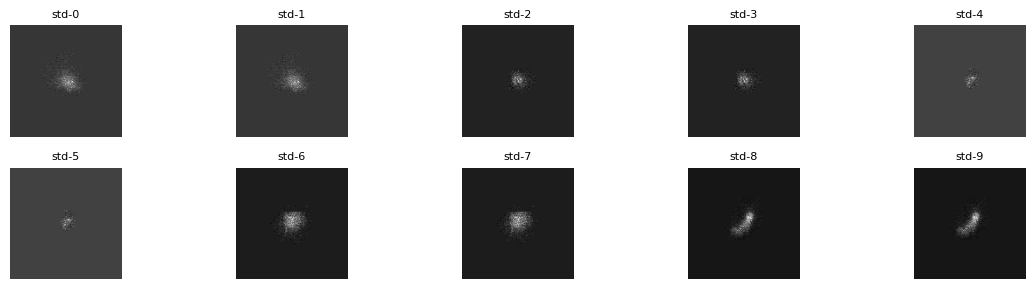

Sample AmBe images:


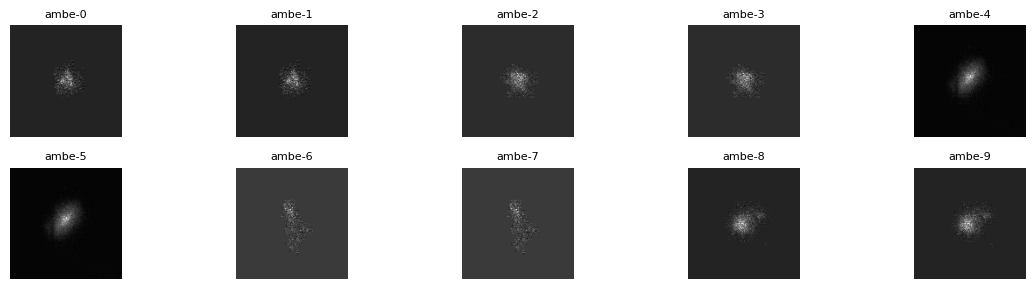

In [10]:
print("Loading images...")
std_images = load_all_images(STD_DIR, img_size=IMG_SIZE)   # label 0
ambe_images = load_all_images(AMBE_DIR, img_size=IMG_SIZE) # label 1

print(f"Loaded {len(std_images)} standard images and {len(ambe_images)} AmBe images.")
print("Sample standard images:")
visualize_grid(std_images[:10], titles=[f"std-{i}" for i in range(10)], ncol=5)
print("Sample AmBe images:")
visualize_grid(ambe_images[:10], titles=[f"ambe-{i}" for i in range(10)], ncol=5)
